In [123]:
import numpy as np
import pandas as pd
import sqlite3
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score




1.read data from csv

In [124]:
#pd = pd.read_csv(path)

2.save data to sqlite

In [125]:
conn = sqlite3.connect("./data/data.db")
#pd.to_sql("data", conn, if_exists="replace", index=False)

3.Load data

In [126]:
df = pd.read_sql_query("SELECT * FROM data", conn)

4.clean the data

In [127]:
print("="*50)
print("Shape of the data:")
print(df.shape)
print("="*50)

Shape of the data:
(7043, 21)


In [128]:
print("="*50)
print("Data types of the columns:")
print(df.dtypes)
print("="*50)

Data types of the columns:
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object


In [129]:
df = df.replace(r'^\s*$', np.nan, regex=True)

In [130]:
print("="*50)
print("Unique values:")
print(df.nunique())
print("="*50)

Unique values:
customerID          7043
gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
tenure                73
PhoneService           2
MultipleLines          3
InternetService        3
OnlineSecurity         3
OnlineBackup           3
DeviceProtection       3
TechSupport            3
StreamingTV            3
StreamingMovies        3
Contract               3
PaperlessBilling       2
PaymentMethod          4
MonthlyCharges      1585
TotalCharges        6530
Churn                  2
dtype: int64


In [131]:
print("="*50)
print("Null values:")
print(df.isnull().sum())
print("="*50)

Null values:
customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64


In [132]:
print("="*50)
print("Missing values:")
print(df.isna().sum())
print("="*50)

Missing values:
customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64


In [133]:
df = df.drop(columns=["customerID"])
df = df.drop_duplicates()
df = df.dropna()

In [134]:
print("="*50)
print("Missing values:")
print(df.isna().sum())
print("="*50)

Missing values:
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [135]:
print("="*50)
print("Data shape:")
print(df.shape)
print("="*50)

Data shape:
(7010, 20)


In [136]:
df.drop(df[df["TotalCharges"] == np.nan].index, inplace=True)

In [137]:
print("="*50)
print("Data shape:")
print(df.shape)
print("="*50)

Data shape:
(7010, 20)


In [138]:
df.reset_index(drop=True, inplace=True)

5. visualisation of the data

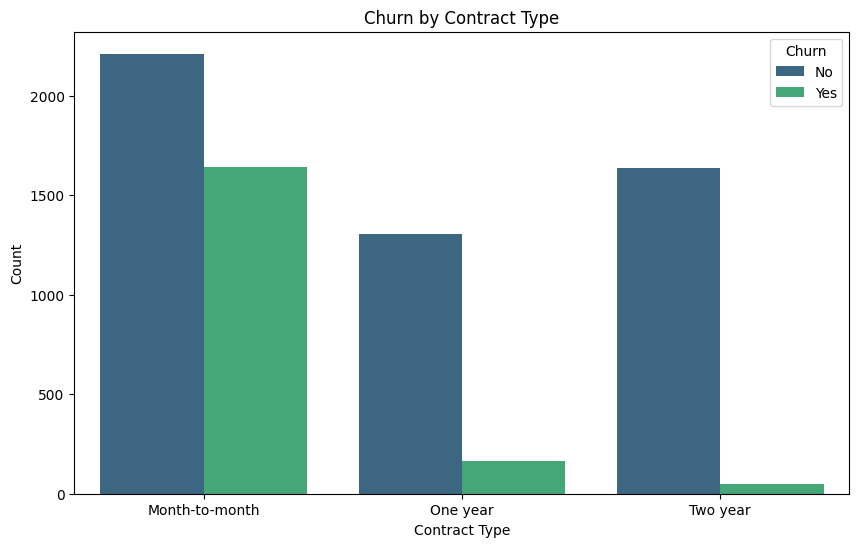

In [139]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x="Contract", hue="Churn", palette="viridis")
plt.title("Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Count")
plt.legend(title="Churn")
plt.show()

In [140]:
print(df.groupby("Contract")["Churn"].value_counts(normalize=True).unstack())

Churn                 No       Yes
Contract                          
Month-to-month  0.573579  0.426421
One year        0.887228  0.112772
Two year        0.971513  0.028487


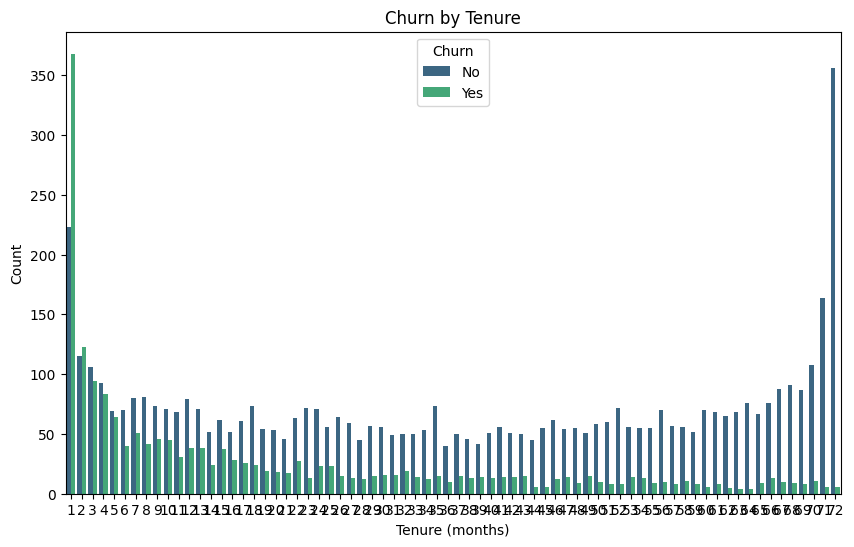

In [141]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x="tenure", hue="Churn", palette="viridis")
plt.title("Churn by Tenure")
plt.xlabel("Tenure (months)")
plt.ylabel("Count")
plt.legend(title="Churn")
plt.show()

In [142]:
print(df.groupby("tenure")["Churn"].value_counts(normalize=True).unstack())

Churn         No       Yes
tenure                    
1       0.377327  0.622673
2       0.483193  0.516807
3       0.530000  0.470000
4       0.528409  0.471591
5       0.518797  0.481203
...          ...       ...
68      0.910000  0.090000
69      0.915789  0.084211
70      0.907563  0.092437
71      0.964706  0.035294
72      0.983425  0.016575

[72 rows x 2 columns]


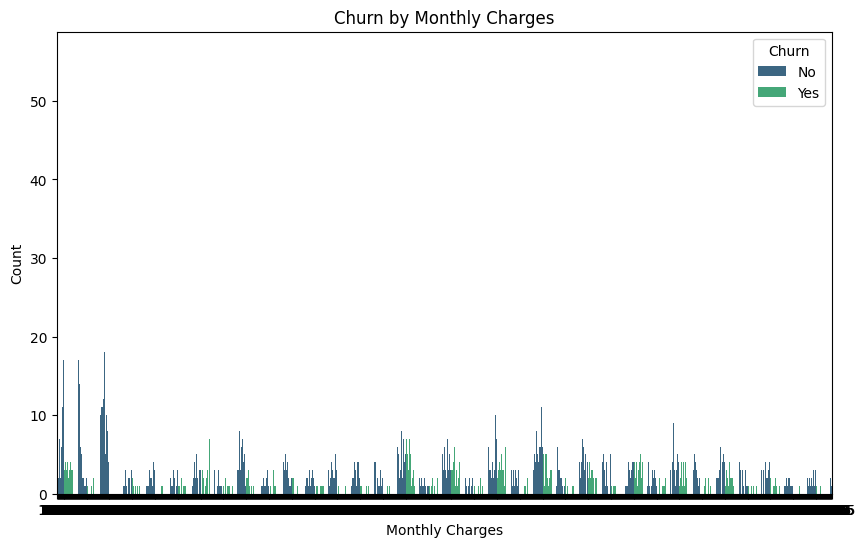

In [143]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x="MonthlyCharges", hue="Churn", palette="viridis")
plt.title("Churn by Monthly Charges")
plt.xlabel("Monthly Charges")
plt.ylabel("Count")
plt.legend(title="Churn")
plt.show()

In [144]:
df["Above_Median_Charges"] = df["MonthlyCharges"] > df["MonthlyCharges"].median()
print(df.groupby("Above_Median_Charges")["Churn"].value_counts(normalize=True).unstack())

Churn                       No       Yes
Above_Median_Charges                    
False                 0.821734  0.178266
True                  0.648402  0.351598


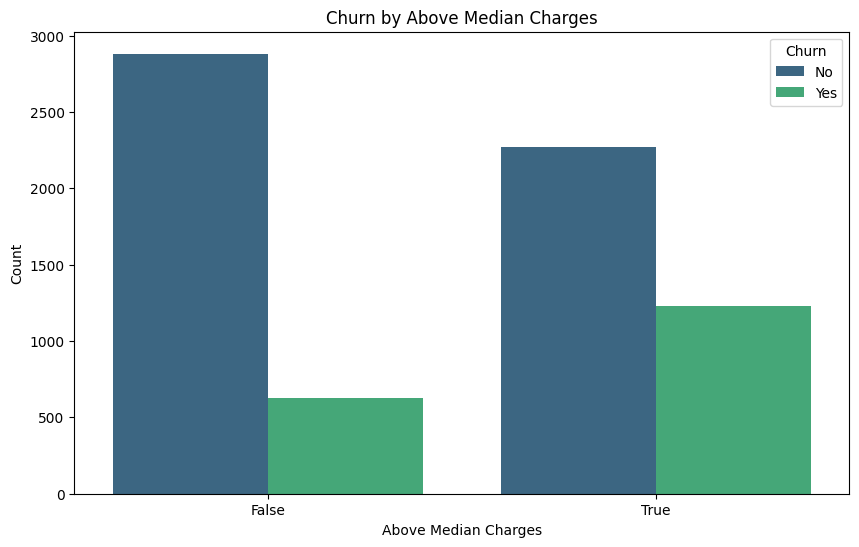

In [145]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x="Above_Median_Charges", hue="Churn", palette="viridis")
plt.title("Churn by Above Median Charges")
plt.xlabel("Above Median Charges")
plt.ylabel("Count")
plt.legend(title="Churn")

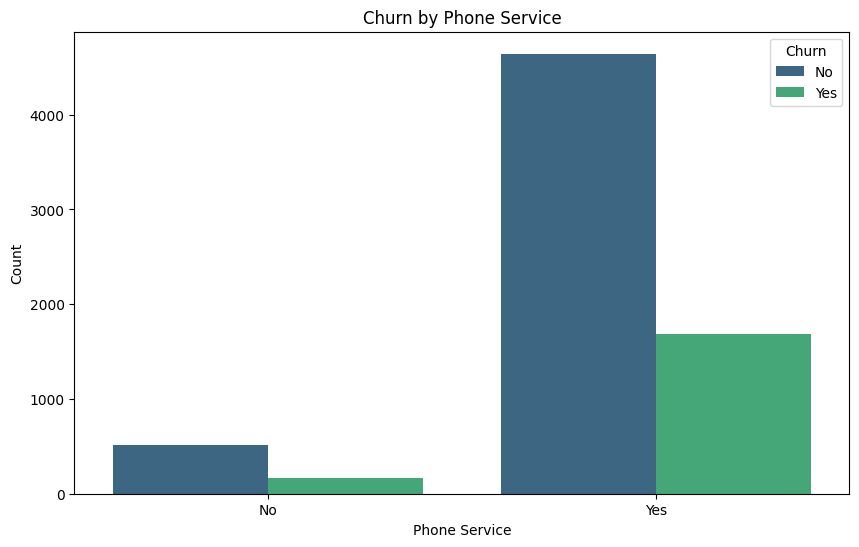

In [146]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x="PhoneService", hue="Churn", palette="viridis")
plt.title("Churn by Phone Service")
plt.xlabel("Phone Service")
plt.ylabel("Count")
plt.legend(title="Churn")

In [147]:
print(df.groupby('PhoneService')['Churn'].value_counts(normalize=True).unstack())

Churn               No       Yes
PhoneService                    
No            0.750000  0.250000
Yes           0.733491  0.266509


In [148]:
print(df.columns)

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn', 'Above_Median_Charges'],
      dtype='str')


In [149]:
colonnes_to_drop = df.columns[df.nunique() > 5].tolist() + ["Churn"]
print(colonnes_to_drop)
for col in colonnes_to_drop:
    if col == "TotalCharges":
        df[col] = df[col].astype(float)
    if col != "Churn" and col != "MonthlyCharges" and df[col].dtype != "string":
        print(f"Processing column: {col}")       
        df[f"{col}_median"] = df[col] < df[col].median()

print(df.columns)

['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']
Processing column: tenure
Processing column: TotalCharges
Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn', 'Above_Median_Charges',
       'tenure_median', 'TotalCharges_median'],
      dtype='str')


In [150]:

colonnes_to_check = df.select_dtypes(include=['object', 'bool','int64']).columns.drop(colonnes_to_drop, errors='ignore')
print(colonnes_to_check)

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod', 'Above_Median_Charges',
       'tenure_median', 'TotalCharges_median'],
      dtype='str')


C:\Users\robin\AppData\Local\Temp\ipykernel_4616\656365938.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  colonnes_to_check = df.select_dtypes(include=['object', 'bool','int64']).columns.drop(colonnes_to_drop, errors='ignore')


In [151]:
for col in colonnes_to_check:
    print(df.groupby(col)['Churn'].value_counts(normalize=True).unstack())

Churn         No       Yes
gender                    
Female  0.731223  0.268777
Male    0.738897  0.261103
Churn                No       Yes
SeniorCitizen                    
0              0.764525  0.235475
1              0.583699  0.416301
Churn          No       Yes
Partner                    
No       0.671551  0.328449
Yes      0.802829  0.197171
Churn             No       Yes
Dependents                    
No          0.688251  0.311749
Yes         0.844688  0.155312
Churn               No       Yes
PhoneService                    
No            0.750000  0.250000
Yes           0.733491  0.266509
Churn                   No       Yes
MultipleLines                       
No                0.751115  0.248885
No phone service  0.750000  0.250000
Yes               0.713515  0.286485
Churn                  No       Yes
InternetService                    
DSL              0.810688  0.189312
Fiber optic      0.582201  0.417799
No               0.927623  0.072377
Churn                  

In [152]:
print(df.columns)

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn', 'Above_Median_Charges',
       'tenure_median', 'TotalCharges_median'],
      dtype='str')


So now 

Processing column: gender
Processing column: SeniorCitizen
Processing column: Partner
Processing column: Dependents
Processing column: PhoneService
Processing column: MultipleLines
Processing column: InternetService
Processing column: OnlineSecurity
Processing column: OnlineBackup
Processing column: DeviceProtection
Processing column: TechSupport
Processing column: StreamingTV
Processing column: StreamingMovies
Processing column: Contract
Processing column: PaperlessBilling
Processing column: PaymentMethod
Processing column: Above_Median_Charges
Processing column: tenure_median
Processing column: TotalCharges_median


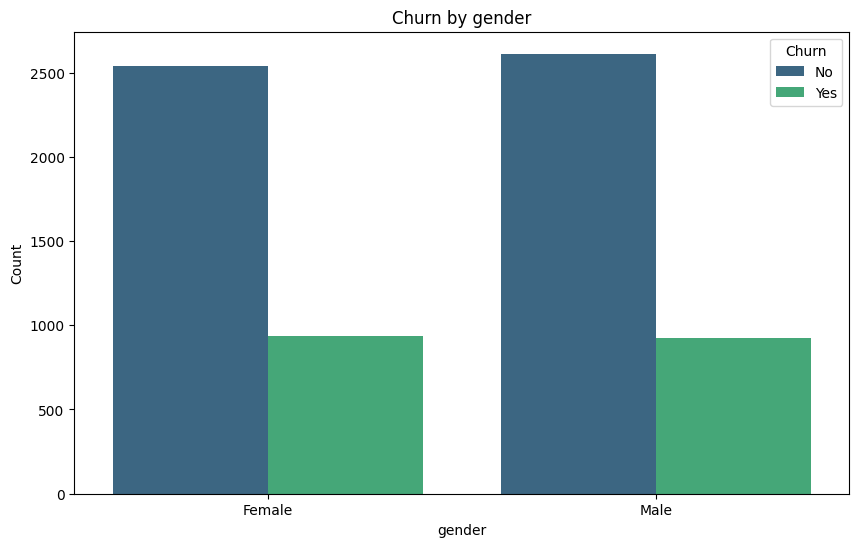

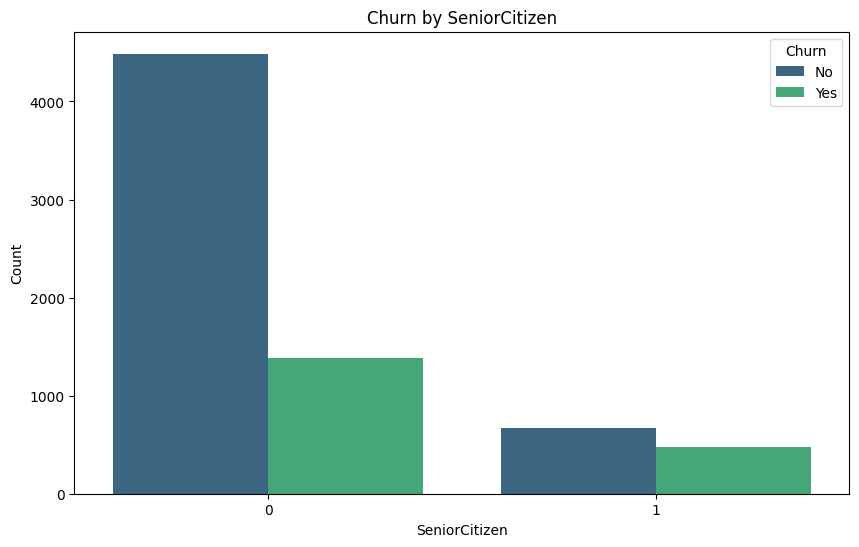

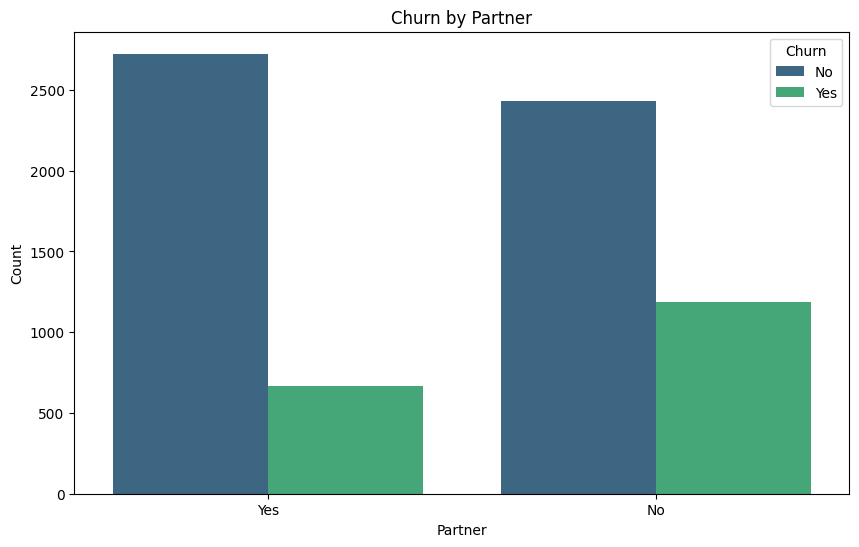

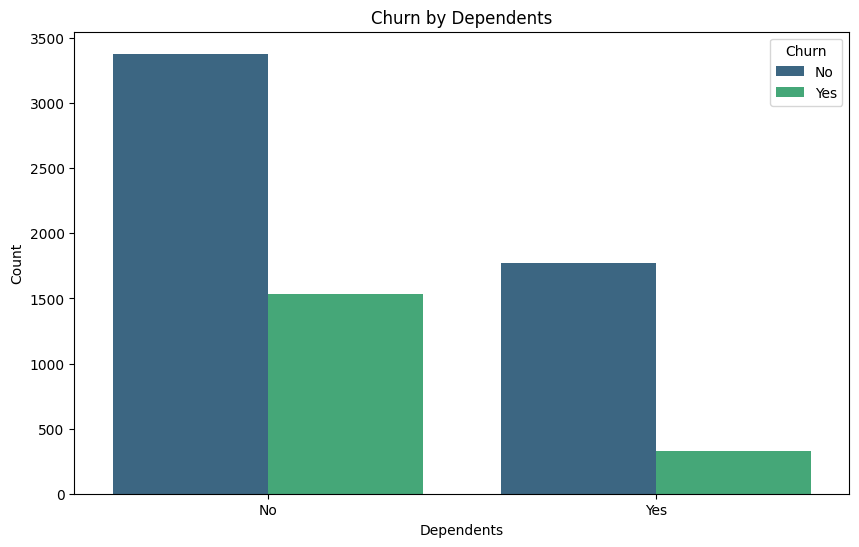

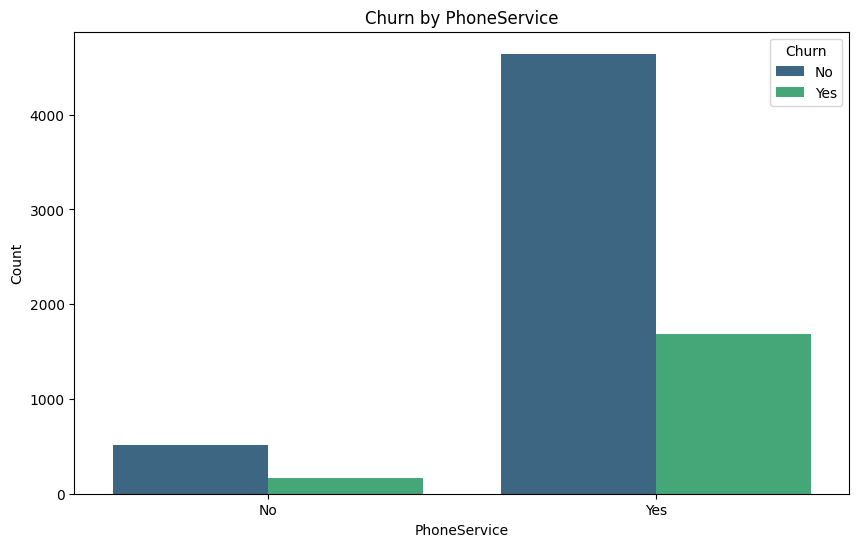

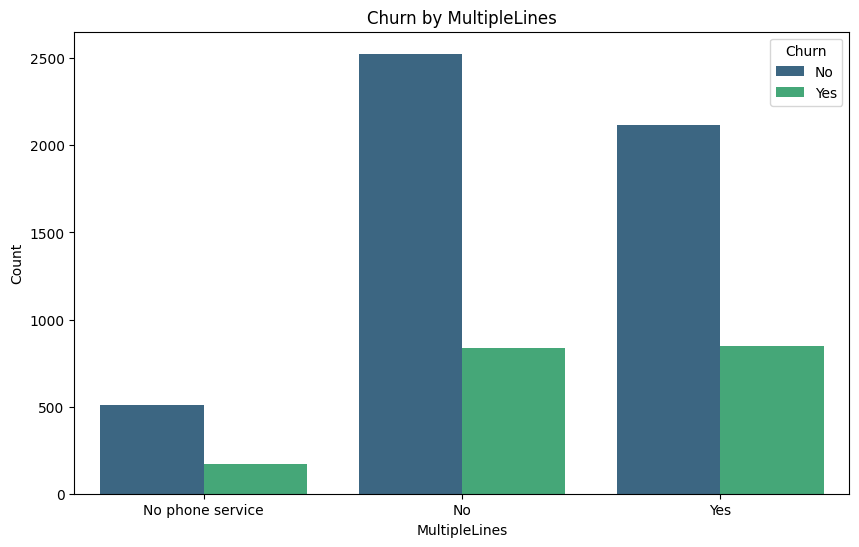

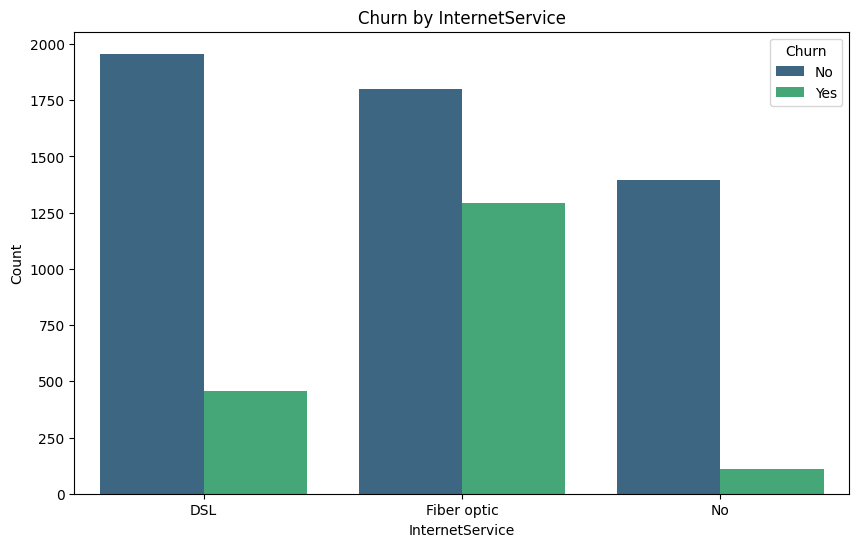

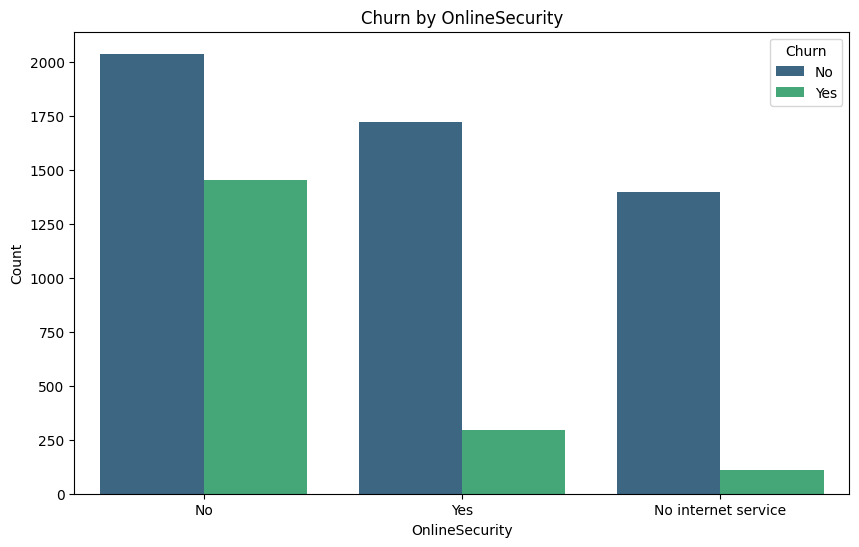

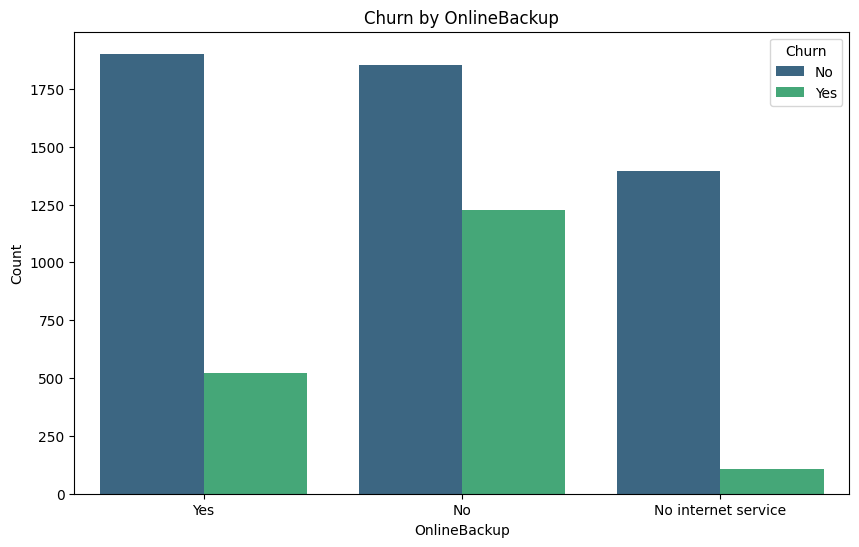

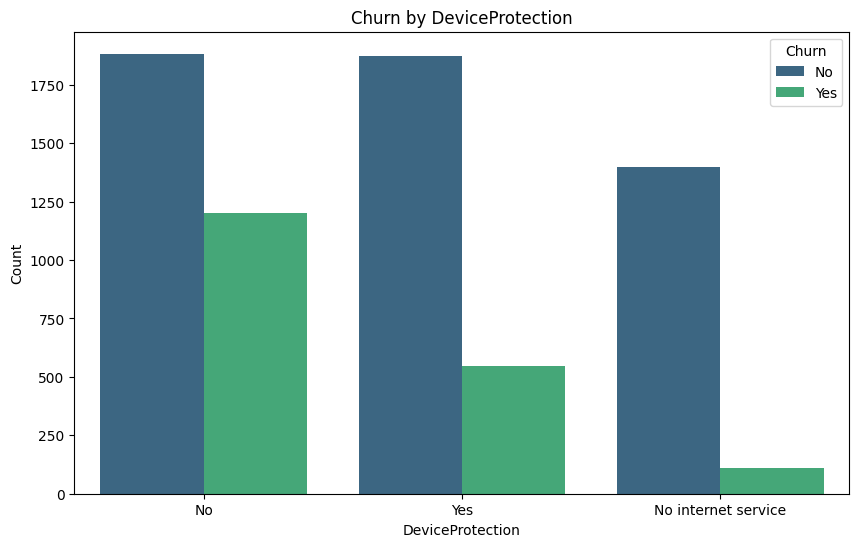

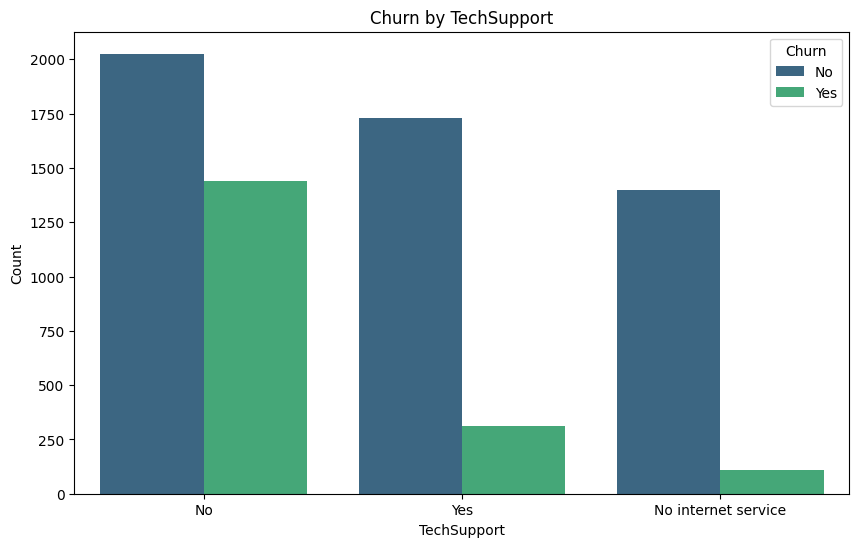

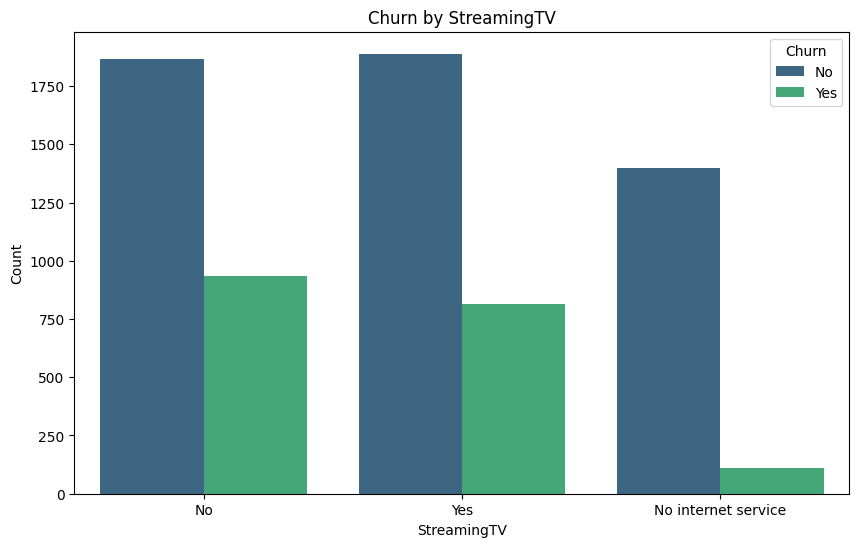

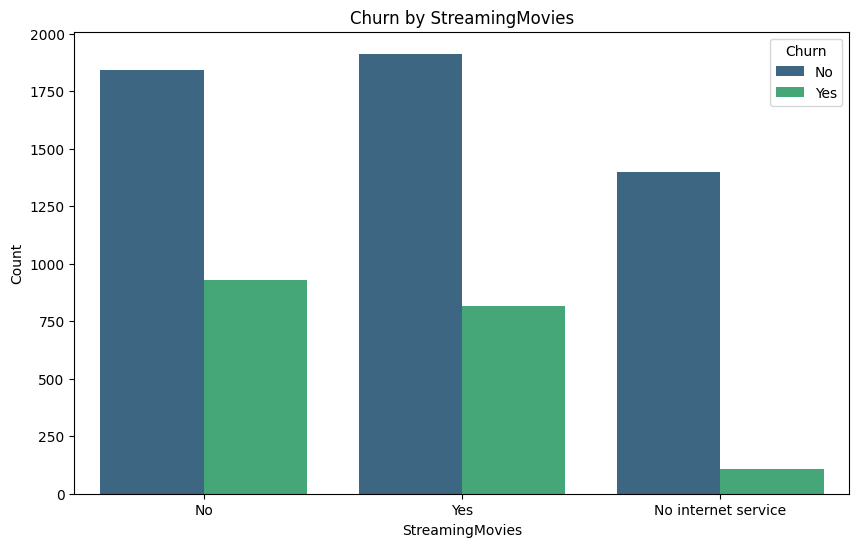

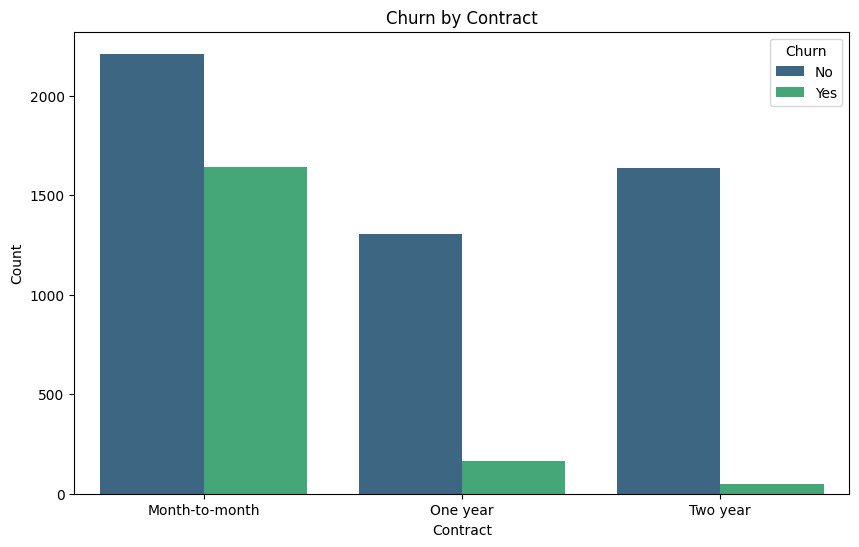

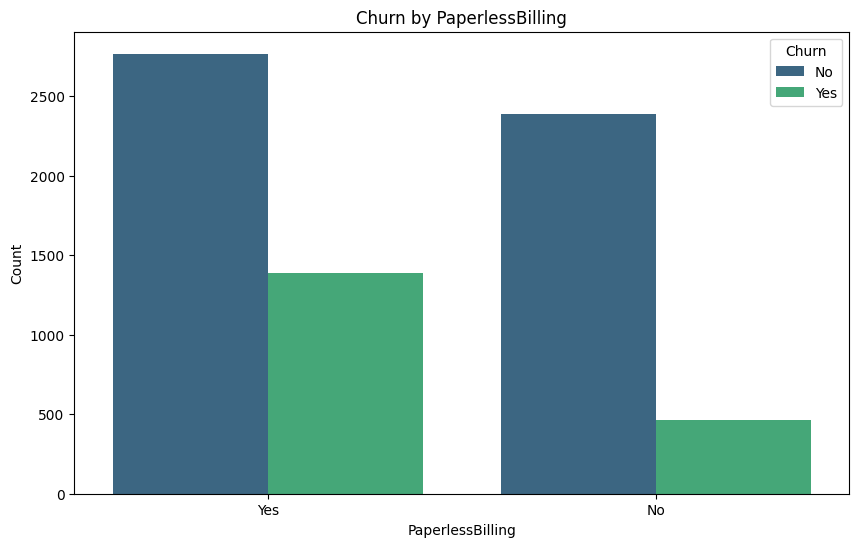

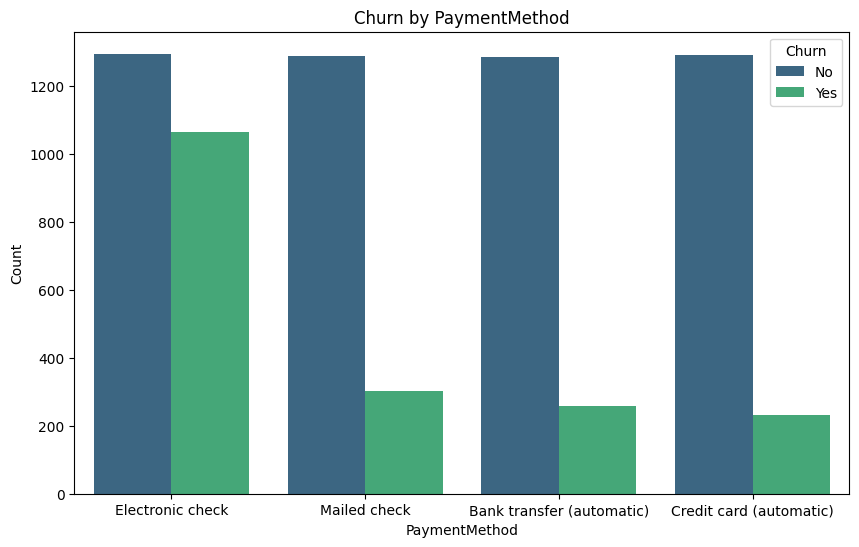

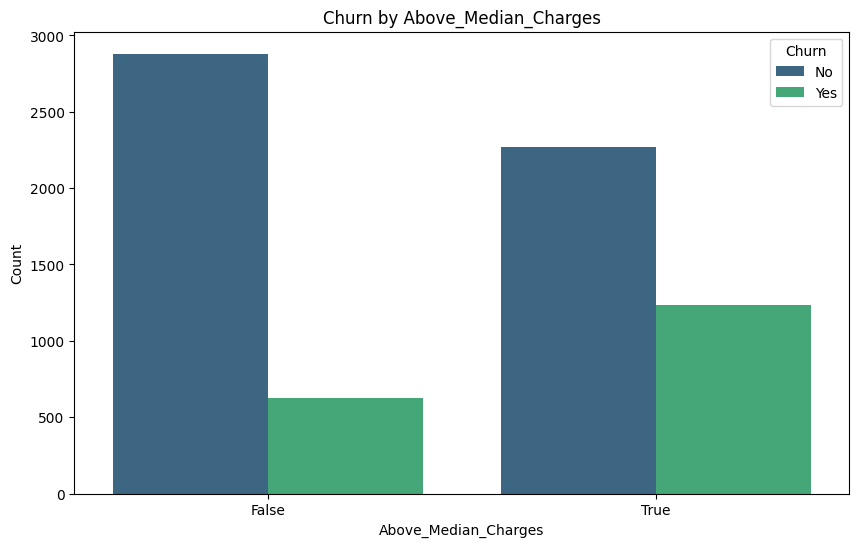

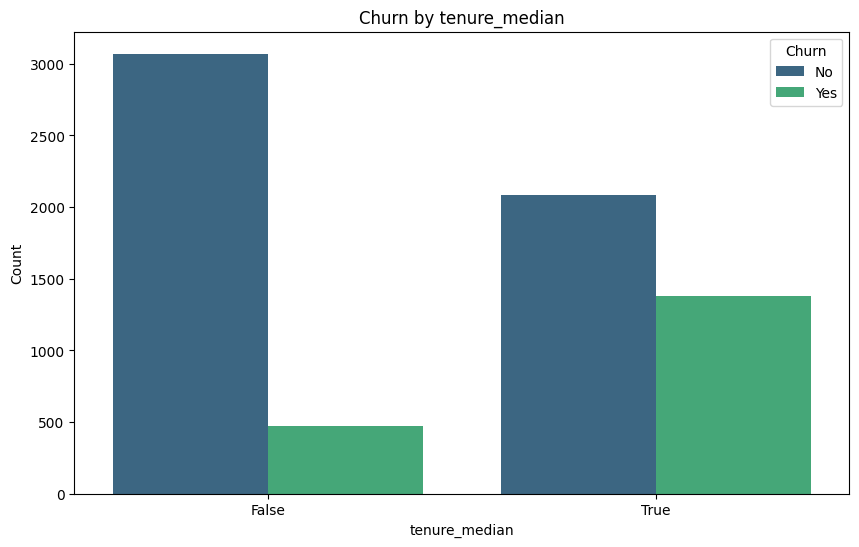

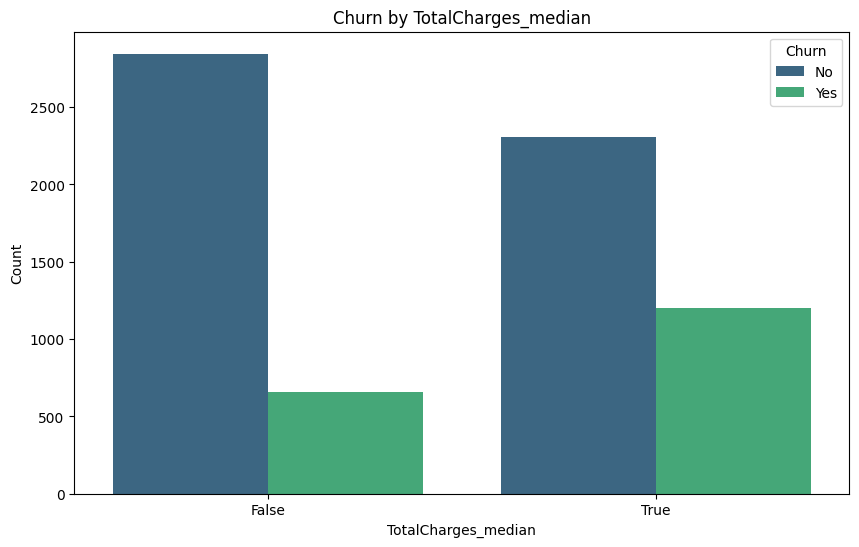

In [153]:
for col in colonnes_to_check:
    print(f"Processing column: {col}")
    plt.figure(figsize=(10, 6))
    sns.countplot(data=df, x=col, hue="Churn", palette="viridis")
    plt.title(f"Churn by {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.legend(title="Churn")

Now that we have vizualised all the columns depends on churn we can see that some columns are better use to know if someone will quit or no.Let's keep this column :Tenure,Montlycharges,partner,dependant,contract,paymentmethod,paperlessBilling,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Total charges,SeniorCitizen                                                      

In [154]:
colonnes_to_keep = ["TotalCharges","tenure","MonthlyCharges","Partner","Dependents",
                    "Contract","PaymentMethod","PaperlessBilling","InternetService",
                    "OnlineSecurity","OnlineBackup","DeviceProtection","TechSupport",
                    "StreamingTV","StreamingMovies","SeniorCitizen","Churn"]

for col in df.columns:
    if col not in colonnes_to_keep:
        df.drop(columns=col, inplace=True)

print(df.columns)

Index(['SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')


In [155]:
print(df.dtypes)

SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                   str
dtype: object


In [156]:
print(df.nunique())

SeniorCitizen          2
Partner                2
Dependents             2
tenure                72
InternetService        3
OnlineSecurity         3
OnlineBackup           3
DeviceProtection       3
TechSupport            3
StreamingTV            3
StreamingMovies        3
Contract               3
PaperlessBilling       2
PaymentMethod          4
MonthlyCharges      1584
TotalCharges        6530
Churn                  2
dtype: int64


In [157]:
for col in df.columns:
    print(f"Processing column: {col} : {df[col].unique()} unique values")

Processing column: SeniorCitizen : [0 1] unique values
Processing column: Partner : <StringArray>
['Yes', 'No']
Length: 2, dtype: str unique values
Processing column: Dependents : <StringArray>
['No', 'Yes']
Length: 2, dtype: str unique values
Processing column: tenure : [ 1 34  2 45  8 22 10 28 62 13 16 58 49 25 69 52 71 21 12 30 47 72 17 27
  5 46 11 70 63 43 15 60 18 66  9  3 31 50 64 56  7 42 35 48 29 65 38 68
 32 55 37 36 41  6  4 33 67 23 57 61 14 20 53 40 59 24 44 19 54 51 26 39] unique values
Processing column: InternetService : <StringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str unique values
Processing column: OnlineSecurity : <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str unique values
Processing column: OnlineBackup : <StringArray>
['Yes', 'No', 'No internet service']
Length: 3, dtype: str unique values
Processing column: DeviceProtection : <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str unique values
Processin

In [158]:
df.to_csv("./data/clean_data.csv")